In [5]:
!pip install h5py

Welcome to Command Prompt


The system cannot find the path specified.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: C:\Users\Erik\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
from scipy import constants
from numpy import unravel_index
from scipy.optimize import curve_fit
from matplotlib.pyplot import figure
import matplotlib.gridspec as gridspec

# sys.path.insert(0, "C:/Users/sr/Documents/Data Analysis/Python Scripts")  
sys.path.insert(0, "C:/Users/Erik/Desktop/Kasevich Lab/ThreePhotonSimulations")  


from h5Manager import ExpViewer

# decaying sine
def expSine(x, A, f, phi, tau, y0):
    return (A*np.sin(2*np.pi*f*t+phi)*np.exp(-t/tau)+y0)


def Sine(t, A, phi, y0):
    return (A*np.sin(t+phi)+y0)

def Sine2(t, A, f, phi, y0):
    return (A*np.sin(2*np.pi*f*t+phi)+y0)

# decaying sine
def gaus(x, m,s,A,y0):
    return (A*np.exp(-(x-m)**2/(2*s**2))+ y0)

# decaying sine
def gaus0(x, s,A):
    return (A*np.exp(-(x)**2/(s**2)))

# decaying sine
def expDecay(x, T, A):
    return (A*np.exp(-x/T))

# decaying sine
def gaus1(x, s,A,y0):
    return (A*np.exp(-(x)**2/(s**2)) + y0)

ModuleNotFoundError: No module named 'h5py'

# Frequency Scan

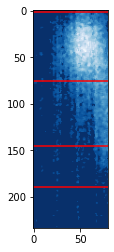

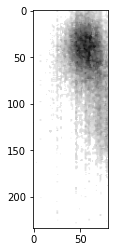

In [135]:
# extract and process images

direc = "C:/Users/sr/Documents/Artiq/artiq-master/results"
RID = 74796
exp = ExpViewer(RID, dir=direc)
ims = np.array(exp.images)

#plt.imshow(exp.images[5])  # check that image looks good
#plt.show()

#ims = ims[:,100:300, 55:130]
ims = ims[:,80:400, 55:135]
threshold =10
ims = np.where(ims > threshold, ims, 0)

bins = (1, 75, 145,190)
for val in bins:
    plt.axhline(val, color='red')
plt.imshow(1-ims[5],cmap=plt.get_cmap('Blues'))  # check that processed image looks good
plt.show()
plt.imshow(1-ims[3],cmap=plt.get_cmap('gray'))  # check that processed image looks good
plt.show()


88135.48387096774


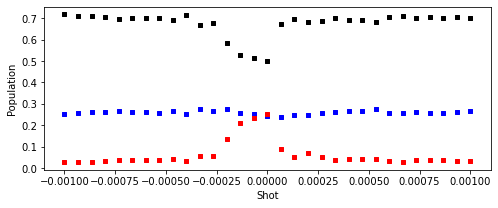

[-3.69570880e-01  1.01602367e-04 -7.97381088e-02  4.81701876e-01]


In [137]:
f = (exp.x-224.9848*1e6)*1e-6

x0 = [np.sum(ims[i,bins[0]:bins[1],:])/np.sum(ims[i,bins[0]:bins[3],:]) for i in range(len(ims))]
x1 = [np.sum(ims[i,bins[1]:bins[2],:])/np.sum(ims[i,bins[0]:bins[3],:]) for i in range(len(ims))]
x2 = [np.sum(ims[i,bins[2]:bins[3],:])/np.sum(ims[i,bins[0]:bins[3],:]) for i in range(len(ims))]
idx = range(len(x0))
atomnumber = [np.sum(ims[i,bins[1]:bins[3],:]) for i in range(len(ims))]
print(np.mean(atomnumber))

plt.figure(figsize=(8,3))
plt.scatter(f,x0, c='black', marker='s',s=10, label='1S0')
plt.scatter(f,x1, c='b', marker='s',s=10, label='3/4 3P2 + 1/4 3P0')
plt.scatter(f,x2, c='r', marker='s',s=10, label='3/4 3P0 + 1/4 3P2')
#plt.scatter(f,xsb, label='right', c='green', marker='s',s=10)

# popt1, pcov1 = curve_fit(gaus,f,x0, p0=[0.1,0.1, 0.5,0], maxfev=20000)
# popt2, pcov2 = curve_fit(gaus,f,x1, p0=[0.1,0.1, 1,0], maxfev=20000)
# popt3, pcov3 = curve_fit(gaus,f,x2, p0=[0, 0.1, -0.6, 0.8], maxfev=20000)
#popt1, pcov1 = curve_fit(Sine2,f,x0, p0=[1,0.0001,0.1, 0.5], maxfev=20000)
#plt.plot(f, Sine2(f, *popt1), c='b')
# plt.plot(f, gaus(f, *popt1), c='b')
# plt.plot(f, gaus(f, *popt2), c='r')
# plt.plot(f, gaus(f, *popt3), c='g')


#plt.legend(loc='upper right')
plt.xlabel('Shot')
#plt.xlabel('Detuning (Hz)')
#plt.xlabel('Pulse duration (us)')
plt.ylabel('Population')

plt.show()

print(popt1)

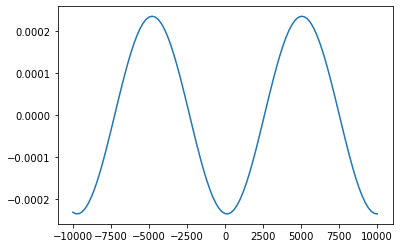

0.00023582711659596208

In [76]:
A1 = popt1[0];
f1 = popt1[1];
phi1=popt1[2];
y01=popt1[3];
#plt.plot(f,A1*np.sin(2*np.pi*f1*f+phi1)+y01)
plt.plot(f,2*np.pi*f1*A1*np.cos(2*np.pi*f1*f+phi1))
plt.show()
dpdf=2*np.pi*f1*A1*np.cos(2*np.pi*f1*(5000)+phi1)
dpdf

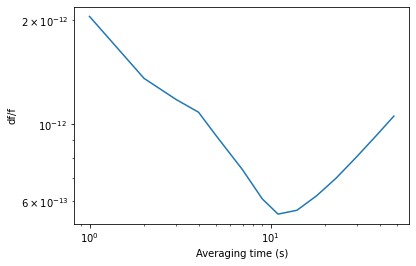

In [89]:
import allantools

t = np.logspace(0, 2, 20)  # tau values from 1 to 1000
y = x0/dpdf  # Convert population to frequency data
r = 1  # sample rate in Hz of the input 
(t2, ad, ade, adn) = allantools.oadev(y, rate=r, data_type="freq", taus=t)  # Compute the overlapping ADEV
fig = plt.loglog(t2, ad/(4*1e14)) # Plot the results
plt.xlabel('Averaging time (s)')
plt.ylabel('df/f')
plt.show()

--- Fit Results ---
Carrier Frequency (f0)  : 0.01 ± 0.00
Carrier Amplitude (A)   : 0.14 ± 0.01
Width (FWHM)            : 0.03 ± 0.00
Sideband Spacing (f_sb) : 0.078 ± 0.00170
Ratio n-1 (r_minus)     : 0.061 ± 0.052
Ratio n+1 (r_plus)      : 0.654 ± 0.052


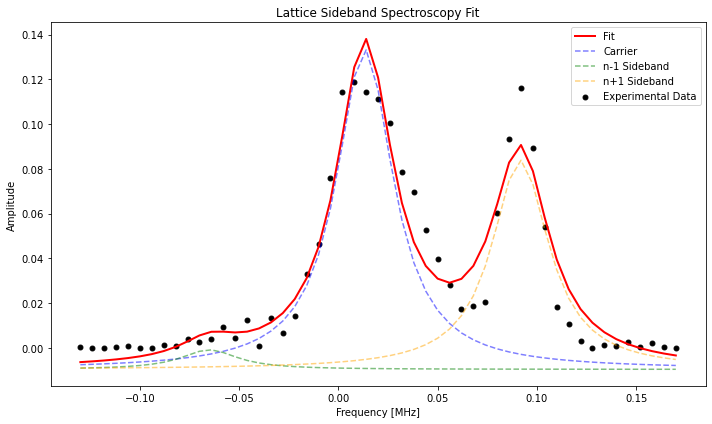

In [353]:
## fitting side band function
y = x2
f = f

def lorentzian(f, f_center, amp, fwhm):
    """Helper function for a single Lorentzian."""
    return amp * (fwhm / 2)**2 / ((f - f_center)**2 + (fwhm / 2)**2)

def sideband_model(f, f0, A, fwhm, f_sb, r_minus, r_plus, y0):
    """
    Model for lattice sideband spectroscopy.
    
    Parameters:
    f       : Array of frequency data
    f0      : Center frequency of the carrier peak
    A       : Amplitude of the carrier peak
    fwhm    : Full width at half maximum (assumed same for all peaks)
    f_sb    : Sideband frequency spacing
    r_minus : Relative height of the n-1 (red) sideband
    r_plus  : Relative height of the n+1 (blue) sideband
    y0      : Constant background offset
    """
    carrier = lorentzian(f, f0, A, fwhm)
    sb_minus = lorentzian(f, f0 - f_sb, A * r_minus, fwhm)
    sb_plus  = lorentzian(f, f0 + f_sb, A * r_plus, fwhm)
    
    return y0 + carrier + sb_minus + sb_plus

initial_guess = [
    -0.01,  # f0 guess (center peak position)
    0.3,   # A guess (center peak height)
    0.05,    # fwhm guess (width of peaks)
    0.06,   # f_sb guess (distance between center and sideband)
    0.5,    # r_minus guess (ratio)
    0.35,    # r_plus guess (ratio)
    np.min(y) # y0 guess (background level)
]

# Set bounds if necessary (e.g., ratios must be > 0, widths > 0)
bounds = (
    [-1, 0, 0, 0, 0, 0, -np.inf], # Lower bounds
    [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf] # Upper bounds
)

popt, pcov = curve_fit(sideband_model, f, y, p0=initial_guess, bounds=bounds)

# Extract fitted parameters and errors (1 standard deviation)
f0_fit, A_fit, fwhm_fit, fsb_fit, r_minus_fit, r_plus_fit, y0_fit = popt
perr = np.sqrt(np.diag(pcov))

# ==========================================
# 3. Print Results & Plot
# ==========================================
print("--- Fit Results ---")
print(f"Carrier Frequency (f0)  : {f0_fit:.2f} ± {perr[0]:.2f}")
print(f"Carrier Amplitude (A)   : {A_fit:.2f} ± {perr[1]:.2f}")
print(f"Width (FWHM)            : {fwhm_fit:.2f} ± {perr[2]:.2f}")
print(f"Sideband Spacing (f_sb) : {fsb_fit:.3f} ± {perr[3]:.5f}")
print(f"Ratio n-1 (r_minus)     : {r_minus_fit:.3f} ± {perr[4]:.3f}")
print(f"Ratio n+1 (r_plus)      : {r_plus_fit:.3f} ± {perr[5]:.3f}")

plt.figure(figsize=(10, 6))
plt.scatter(f, y, label='Experimental Data', color='k', s=24, alpha=1)
plt.plot(f, sideband_model(f, *popt), label='Fit', color='red', linewidth=2)

# Optional: Plot individual components for visual clarity
plt.plot(f, lorentzian(f, f0_fit, A_fit, fwhm_fit) + y0_fit, '--', color='blue', alpha=0.5, label='Carrier')
plt.plot(f, lorentzian(f, f0_fit - fsb_fit, A_fit * r_minus_fit, fwhm_fit) + y0_fit, '--', color='green', alpha=0.5, label='n-1 Sideband')
plt.plot(f, lorentzian(f, f0_fit + fsb_fit, A_fit * r_plus_fit, fwhm_fit) + y0_fit, '--', color='orange', alpha=0.5, label='n+1 Sideband')
#plt.plot(f, sideband_model(f, *initial_guess), '--', color='purple', alpha=0.5, label='Guess')
plt.xlabel('Frequency [MHz]')
plt.ylabel('Amplitude')
plt.title('Lattice Sideband Spectroscopy Fit')
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
fall = f
xall = x2

In [95]:
.07*1.5/1.1

0.09545454545454546

### TOF images

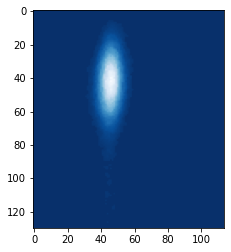

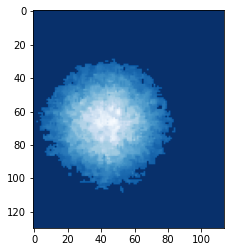

In [487]:
# extract and process images

direc = "C:/Users/sr/Documents/Artiq/artiq-master/results"
RID = 74467
exp = ExpViewer(RID, dir=direc)
ims = np.array(exp.images)

#plt.imshow(exp.images[5])  # check that image looks good
#plt.show()

#ims = ims[:,100:300, 55:130]
ims = ims[:,200:360, 55:185]
threshold =20
ims = np.where(ims > threshold, ims, 0)

plt.imshow(1-np.array(ims[0]).T,cmap=plt.get_cmap('Blues'))  # check that processed image looks good
plt.show()
plt.imshow(1-np.array(ims[10]).T,cmap=plt.get_cmap('Blues'))  # check that processed image looks good
plt.show()


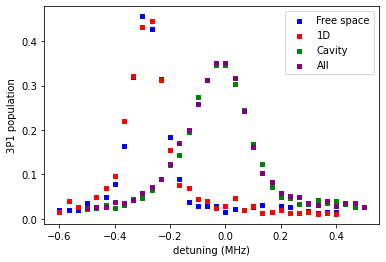

136.64970240382127
143.26711801559733
0.9362203961902236
1.7584253665822562


In [209]:
plt.scatter(fFS,xFS, label='Free space', c='blue', marker='s',s=10)
plt.scatter(f1d,x1d, label='1D', c='red', marker='s',s=10)
plt.scatter(fc,xc, label='Cavity', c='green', marker='s',s=10)
plt.scatter(fall,xall, label='All', c='purple', marker='s',s=10)
plt.legend()

popt1, pcov1 = curve_fit(gaus,fFS,xFS, p0=[-0.4,0.1, 1,0], maxfev=20000)
popt2, pcov2 = curve_fit(gaus,f1d,x1d, p0=[-0.4,0.1, 1,0], maxfev=20000)
#plt.plot(f, gaus(f, *popt1), c='b')
#plt.plot(f, gaus(f, *popt2), c='r')
plt.xlabel('detuning (MHz)')
plt.ylabel('3P1 population')
plt.show()
print(popt1[1]*2.355*10**3)
print(popt2[1]*2.355*10**3)
print(np.sqrt(pcov1[1,1])*10**3)
print(np.sqrt(pcov2[1,1])*10**3)

In [168]:
x3=x2

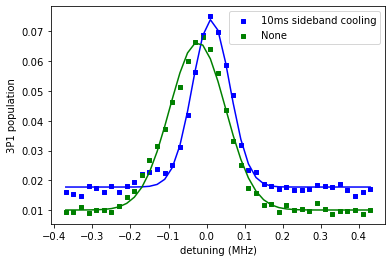

0.11592639044790996
0.17277093437277885


In [144]:
f = (exp.x*1e-6)-180.47
x0 = [np.sum(ims[i,bins[0]:bins[1],:])/np.sum(ims[i,bins[0]:bins[3],:]) for i in range(len(ims))]
x1 = [np.sum(ims[i,bins[1]:bins[2],:])/np.sum(ims[i,bins[1]:bins[3],:]) for i in range(len(ims))]
x2 = [np.sum(ims[i,bins[2]:bins[3],:])/np.sum(ims[i,bins[1]:bins[3],:]) for i in range(len(ims))]

#plt.scatter(f,x0, label='1S0', c='blue', marker='s',s=10)
#plt.scatter(f,xa, label=' ', c='red', marker='s',s=10)
plt.scatter(f,xb, label='10ms sideband cooling', c='blue', marker='s',s=10)
plt.scatter(f,xc, label='None', c='green', marker='s',s=10)
plt.legend()

popt1, pcov1 = curve_fit(gaus,f,xa, p0=[0.0,0.1, 1,0], maxfev=20000)
popt2, pcov2 = curve_fit(gaus,f,xb, p0=[0,0.1, 1,0], maxfev=20000)
popt3, pcov3 = curve_fit(gaus,f,xc, p0=[0,0.1, 1,0], maxfev=20000)
#plt.plot(f, gaus(f, *popt1), c='r')
plt.plot(f, gaus(f, *popt2), c='b')
plt.plot(f, gaus(f, *popt3), c='g')

plt.xlabel('detuning (MHz)')
plt.ylabel('3P1 population')

plt.show()
print(popt2[1]*2.355)
print(popt3[1]*2.355)

In [120]:
180.44384035221992  -0.08

180.3638403522199

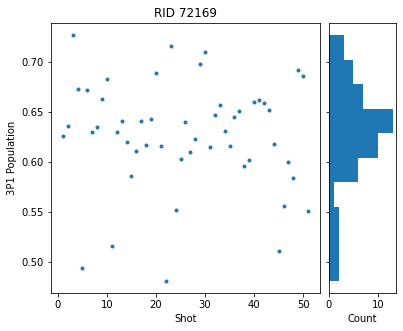

0.05345060459778248
0.626774365917989


In [442]:
x = np.linspace(1,len(x2[51:]),len(x2[51:]))
y = x2[51:]

fig = plt.figure(figsize=(6, 6))
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.05, hspace=0.05)

ax_scatter = fig.add_subplot(gs[1, 0])
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

ax_scatter.scatter(x, y, marker='.')

ax_histy.hist(y, bins=10, orientation='horizontal', align='mid')

ax_histy.yaxis.set_tick_params(labelleft=False)

ax_scatter.set(xlabel="Shot", ylabel="3P1 Population")
ax_histy.set(xlabel='Count')
ax_scatter.set(title="RID 72169")

plt.show()
print(np.std(x2[51:]))
print(np.mean(x2[51:]))

0.27588650664655234
0.1830581220203153


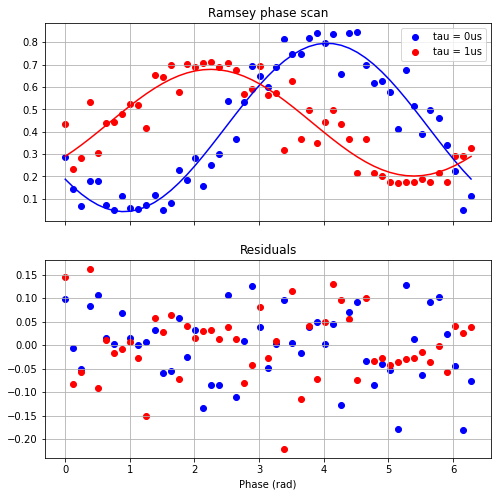

0.07587700476336429


0.07250298459863078

In [349]:
fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True,figsize=(8,8))


d1 = x2[:51]
d2 = x2[51:]

popt1, pcov1 = curve_fit(Sine,p,d1, p0=[1, 1,0], maxfev=20000)
popt2, pcov2 = curve_fit(Sine,p,d2, p0=[1, 1,0], maxfev=20000)

# Plot data on each axes object
ax1.scatter(p, d1, color='b', label = "tau = 0us")
ax1.scatter(p, d2, color='r', label = "tau = 1us")
print(np.std(d1))
print(np.std(d2))

ax1.plot(p, Sine(p, *popt1), c='b')
ax1.plot(p, Sine(p, *popt2), c='r')
ax1.set_title('Ramsey phase scan')
ax1.grid(True)
ax1.legend()

ax2.scatter(p,d1-Sine(p, *popt1),color='b')
ax2.scatter(p,d2-Sine(p, *popt2),color='r')
ax2.set_xlabel('Phase (rad)') # Label only the bottom axis
ax2.set_title('Residuals')
ax2.grid(True)

# Optional: Adjust spacing between subplots for a more "connected" look
plt.subplots_adjust(hspace=0.2) 

plt.show()

print(np.sqrt(np.mean(np.array((d1-Sine(p, *popt1))**2))))
np.sqrt(np.mean(np.array((d2-Sine(p, *popt2))**2)))

std residuals, m=+1, 0us, 1us: 0.07641604679172802 0.08302890948981623
std residuals, m=0, 0us, 1us: 0.08943958923328625 0.06013538121647851


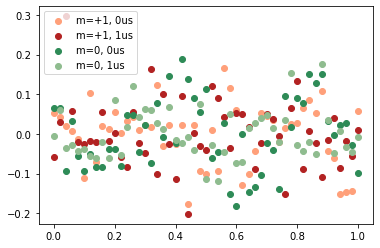

In [309]:
#res1=d1-Sine(p, *popt1)
#res2=d2-Sine(p, *popt2)

plt.scatter(f,res1,color='lightsalmon'); plt.scatter(f,res2,color='firebrick');
plt.scatter(f,d1-Sine(p, *popt1),color='seagreen'); plt.scatter(f,d2-Sine(p, *popt2),color='darkseagreen')
plt.legend(['m=+1, 0us','m=+1, 1us','m=0, 0us','m=0, 1us'])

print('std residuals, m=+1, 0us, 1us:', np.std(res1), np.std(res2))
print('std residuals, m=0, 0us, 1us:', np.std(d1-Sine(p, *popt1)),np.std(d2-Sine(p, *popt2)))

## Image analysis

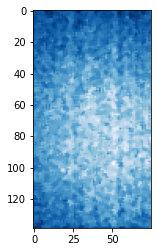

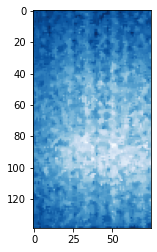

In [13]:
# extract and process images

direc = "C:/Users/sr/Documents/Artiq/artiq-master/results"
RID = 73139

exp = ExpViewer(RID, dir=direc)
ims = np.array(exp.images)

#plt.imshow(exp.images[5])  # check that image looks good
#plt.show()

#ims = ims[:,100:300, 55:130]
ims = ims[:,175:400, 125:200]
threshold = 10
ims = np.where(ims > threshold, ims, 0)

plt.imshow(1-ims[9],cmap=plt.get_cmap('Blues'))  # check that processed image looks good
plt.show()

plt.imshow(1-ims[14],cmap=plt.get_cmap('Blues'))  # check that processed image looks good
plt.show()

In [9]:
margx = [np.sum(ims[1,i,:]) for i in range(len(ims[1]))]
margy = [np.sum(ims[1,:,i]) for i in range(len(np.transpose(ims[1])))]

margx2 = [np.sum(ims[9,i,:]) for i in range(len(ims[9]))]
margy2 = [np.sum(ims[9,:,i]) for i in range(len(np.transpose(ims[9])))]

margx3 = [np.sum(ims[14,i,:]) for i in range(len(ims[14]))]
margy3 = [np.sum(ims[14,:,i]) for i in range(len(np.transpose(ims[14])))]

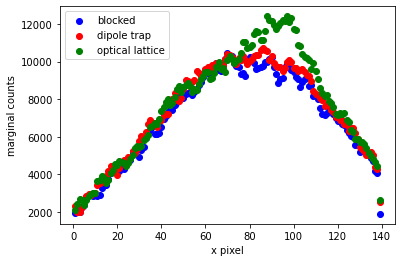

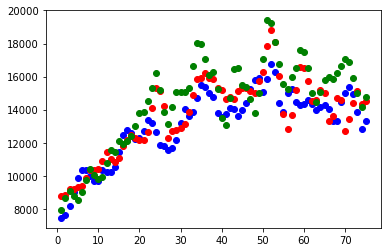

In [12]:
x = np.linspace(1,len(margx),len(margx))
x2 = np.linspace(1,len(margx2),len(margx2))
x3 = np.linspace(1,len(margx3),len(margx3))

plt.scatter(x,margx,color='blue',label='blocked')
plt.scatter(x2,margx2,color='red',label='dipole trap')
plt.scatter(x3,margx3,color='green',label='optical lattice')

plt.xlabel('x pixel')
plt.ylabel('marginal counts')
plt.legend()
plt.show()

y = np.linspace(1,len(margy),len(margy))
y2 = np.linspace(1,len(margy2),len(margy2))
y3 = np.linspace(1,len(margy3),len(margy3))

plt.scatter(y,margy,color='blue')
plt.scatter(y2,margy2,color='red')
plt.scatter(y3,margy3,color='green')

plt.show()

[32.84920498  0.51215178  0.        ]
[23.98513044  0.64976091  0.        ]
[29.86554202  0.58878915  0.        ]


C:\Users\sr\Anaconda3\lib\site-packages\scipy\optimize\minpack.py:828: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
C:\Users\sr\Anaconda3\lib\site-packages\scipy\optimize\minpack.py:828: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
C:\Users\sr\Anaconda3\lib\site-packages\scipy\optimize\minpack.py:828: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


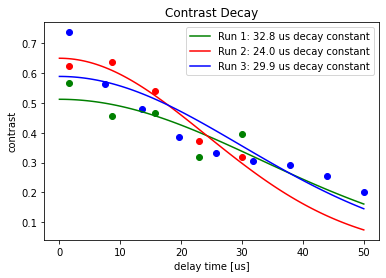

In [293]:
x1 = np.linspace(0,50,100)
popt, pcov = curve_fit(gaus0,x_exp1*1e6,y_exp1/1e6, p0=[10, 1,0], maxfev=20000)
plt.plot(x1, gaus0(x1, *popt), c='g')
print(popt)

plt.scatter(x_exp1*1e6,y_exp1/1e6,c='g')
plt.scatter(x_exp2*1e6,y_exp2/1e6,c='r')
plt.scatter(x_exp3*1e6,y_exp3/1e6,c='b')

popt, pcov = curve_fit(gaus0,x_exp2*1e6,y_exp2/1e6, p0=[10, 1,0], maxfev=20000)
plt.plot(x1, gaus0(x1, *popt), c='r')
print(popt)

popt, pcov = curve_fit(gaus0,x_exp3*1e6,y_exp3/1e6, p0=[10, 1,0], maxfev=20000)
plt.plot(x1, gaus0(x1, *popt), c='b')
print(popt)

plt.xlabel('delay time [us]')
plt.ylabel('contrast')
plt.title('Contrast Decay')
plt.legend(['Run 1: 32.8 us decay constant','Run 2: 24.0 us decay constant','Run 3: 29.9 us decay constant'])

[19.80935294  0.58513412]
[22.76991072  0.55615932]


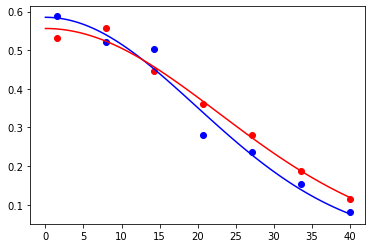

In [160]:
x1 = np.linspace(0,40,100)
popt1, pcov1 = curve_fit(gaus0,r1x,r1y, p0=[10, 1], maxfev=20000)
plt.plot(x1, gaus0(x1, *popt1), c='b')

popt, pcov = curve_fit(gaus0,exp.x*1e6,exp.y/1e6, p0=[10, 1], maxfev=20000)
plt.plot(x1, gaus0(x1, *popt), c='r')

plt.scatter(r1x,r1y,c='b')
plt.scatter(exp.x*1e6,exp.y/1e6,c='r')

print(popt1)
print(popt)

### Batman

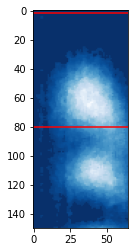

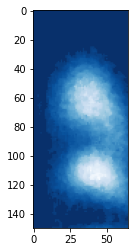

{'scale_3D': 0.8, 'atten_3D': 6.0, 'freq_3D': 180000000.0, 'scale_3P0_repump': 0.8, 'atten_3P0_repump': 2.0, 'freq_3P0_repump': 210000000.0, 'scale_3P2_repump': 0.8, 'atten_3P2_repump': 6.0, 'freq_3P2_repump': 80000000.0, 'scale_3D_red': 0.8, 'atten_3D_red': 9.0, 'freq_3D_red': 180000000.0, 'bmot_ramp_duration': 0.05, 'bmot_current': 5.0, 'bmot_load_duration': 1.0, 'Npoints': 60.0, 'rmot_bb_current': 0.4, 'rmot_bb_duration': 0.05, 'rmot_ramp_duration': 0.085, 'rmot_sf_current': 2.0, 'rmot_sf_duration': 0.025, 'rmot_freq_i': 180500000.0, 'rmot_freq_depth_i': 6000000.0, 'rmot_freq_f': 180160000.0, 'rmot_freq_depth_f': 1100000.0, 'nprofiles': 7.0, 'rmot_scan_frequency': 30000.0, 'molasses': False, 'molasses_frequency': 179250000.0, 'Push_pulse_time': 7e-07, 'Detection_pulse_time': 2e-05, 'Delay_duration': 0.0009, 'Exposure_Time': 0.0005, 'Hardware_Gain': 150.0, 'Median_Filter': True, 'Gaussian_Filter': False, 'scale_688': 0.8, 'atten_688': 8.0, 'freq_688': 80000000.0, 'scale_Push': 0.8, '

In [2]:
# extract and process images

direc = "C:/Users/sr/Documents/Artiq/artiq-master/results"
RID = 71838

exp = ExpViewer(RID, dir=direc)
ims = np.array(exp.images)

#plt.imshow(exp.images[5])  # check that image looks good
#plt.show()

ims = ims[:,100:250, 55:120]
threshold = 10
ims = np.where(ims > threshold, ims, 0)

bins = (1, 80, 150)
for val in bins:
    plt.axhline(val, color='red')
plt.imshow(1-ims[10],cmap=plt.get_cmap('Blues'))  # check that processed image looks good
plt.show()
plt.imshow(1-ims[1],cmap=plt.get_cmap('Blues'))  # check that processed image looks good
plt.show()

f = exp.x*1e-6
y = exp.y/np.max(exp.y)

print(exp.parameters)

In [4]:
f = 2*np.pi*np.linspace(0,2,15)
x1 = [np.sum(ims[i,bins[1]:bins[2],:])/np.sum(ims[i,bins[0]:bins[2],:]) for i in range(len(f))]
x2 = [np.sum(ims[i,bins[1]:bins[2],:])/np.sum(ims[i,bins[0]:bins[2],:]) for i in range(len(f),2*len(f))]
x3 = [np.sum(ims[i,bins[1]:bins[2],:])/np.sum(ims[i,bins[0]:bins[2],:]) for i in range(2*len(f),3*len(f))]
x4 = [np.sum(ims[i,bins[1]:bins[2],:])/np.sum(ims[i,bins[0]:bins[2],:]) for i in range(3*len(f),4*len(f))]

IndexError: index 15 is out of bounds for axis 0 with size 15

[ 0.31255033 -0.41118849  0.44254474]


array([0.22939751, 0.25928997, 0.44869875])

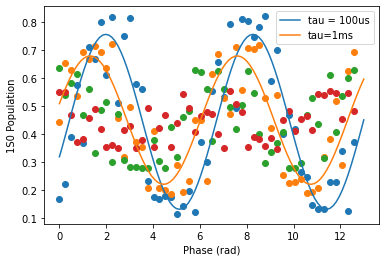

In [52]:
plt.scatter(f,x1)
plt.scatter(f,x2)
plt.scatter(f,x3)
plt.scatter(f,x4)

plt.ylabel('1S0 Population')
plt.xlabel('Phase (rad)')

tfit = np.linspace(0,13,100)
popt, pcov = curve_fit(Sine,f,x1, p0=[1, 0,0.5], maxfev=20000)
plt.plot(tfit, Sine(tfit, *popt))
print(popt)

popt, pcov = curve_fit(Sine,f,x2, p0=[1, 0,0.5], maxfev=20000)
plt.plot(tfit, Sine(tfit, *popt))
plt.legend(['tau = 100us','tau=1ms'])
popt

[-0.05583976 -1.02500151  0.44016965]


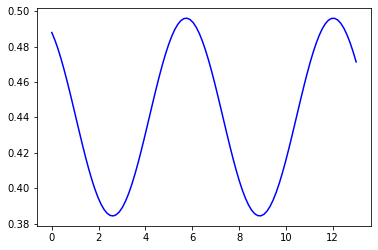

In [55]:
tfit = np.linspace(0,13,100)
popt, pcov = curve_fit(Sine,f,x4, p0=[1, 0,0.5], maxfev=20000)
plt.plot(tfit, Sine(tfit, *popt), c='b')
print(popt)

In [61]:
times = [100,730, 1370, 2000]
amps = [2*0.313,2*0.229,2*0.13,2*0.056]
pks = [0.763, 0.580, 0.389, 0.221]

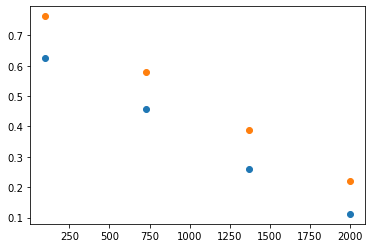

In [63]:
plt.scatter(times,amps)
plt.scatter(times,pks)

plt.show()

In [64]:
1/2.71

0.36900369003690037

Text(0.5, 0, '1S0 Population')

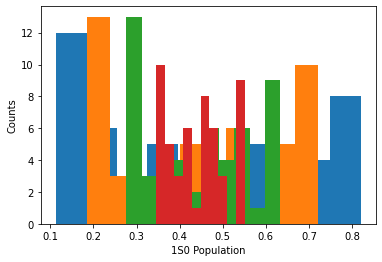

In [50]:
plt.hist(x1)
plt.hist(x2)
plt.hist(x3)
plt.hist(x4)
plt.ylabel('Counts')
plt.xlabel('1S0 Population')

In [38]:
0.2/0.307063

0.6513321370533084

array([5.85856891, 0.7063029 ])

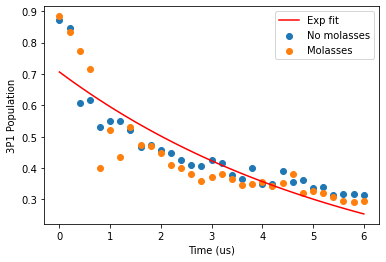

In [193]:
f6 = np.linspace(6,0,31)
plt.scatter(f6,x1_6)
plt.scatter(f6,x1_m6)


plt.ylabel('3P1 Population')
plt.xlabel('Time (us)')


tfit = np.linspace(0,6,100)
popt, pcov = curve_fit(expDecay,f6[2:],x1_6[2:], p0=[1, 21], maxfev=20000)
plt.plot(tfit, expDecay(tfit, *popt), c='r')
plt.legend(['Exp fit','No molasses','Molasses'])
popt

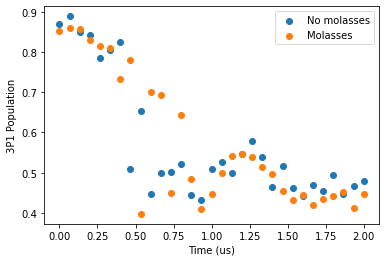

In [194]:
f2 = np.linspace(2,0,31)
plt.scatter(f2,x1_2)
plt.scatter(f2,x1_m2)



plt.ylabel('3P1 Population')
plt.xlabel('Time (us)')
plt.legend(['No molasses','Molasses'])

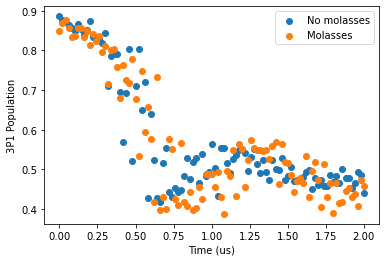

In [202]:
plt.scatter(f2long,x1_2long)
plt.scatter(fm2long,x1_m2long)



plt.ylabel('3P1 Population')
plt.xlabel('Time (us)')
plt.legend(['No molasses','Molasses'])

In [134]:
x1_m=x1

In [35]:
f0=np.concatenate([np.linspace(0,0.01,int(len(ims)/12)),np.linspace(100,100.01,int(len(ims)/12)),np.linspace(200,200.01,int(len(ims)/12)),
               np.linspace(300,300.01,int(len(ims)/12)),np.linspace(400,400.01,int(len(ims)/12)),np.linspace(500,500.01,int(len(ims)/12)),
               np.linspace(600,600.01,int(len(ims)/12)),np.linspace(700,700.01,int(len(ims)/12)),np.linspace(800,800.01,int(len(ims)/12)),
               np.linspace(900,900.01,int(len(ims)/12)),np.linspace(1000,1000.01,int(len(ims)/12)),np.linspace(1100,1100.01,int(len(ims)/12))])

In [4]:
#f = np.linspace(0,len(ims),len(ims))
tmax = 3000
f = np.linspace(0,2*np.pi*len(ims)/100,len(ims))
tramsey = np.linspace(0.01*tmax,tmax,len(ims))
#techo = np.linspace(0.01*tmax,2*tmax,len(ims))

x0_m = [np.sum(ims[i,bins[0]:bins[1],:])/np.sum(ims[i,bins[0]:bins[2],:]) for i in range(len(f))]
x1_m = [np.sum(ims[i,bins[1]:bins[2],:])/np.sum(ims[i,bins[0]:bins[2],:]) for i in range(len(f))]
#x2 = [np.sum(ims[i,bins[2]:bins[3],:])/np.sum(ims[i,bins[0]:bins[3],:]) for i in range(len(f))]
#print(np.std(x0))
#print(np.std(x1))
#print(np.std(x2))
#x0XY=x0
#tXY = np.linspace(0.01*tmax,tmax,len(ims))
#lt.scatter(tramsey,x0, label='1S0', c='red', marker='s',s=10)

#contrast_nm=[];
contrast_m=[];

for n in range(7):
    #contrast_nm.append(max(x1_nm[(n*20):((n+1)*20)])-min(x1_nm[(n*20):((n+1)*20)]))
    contrast_m.append(max(x1_m[(n*20):((n+1)*20)])-min(x1_m[(n*20):((n+1)*20)]))

plt.scatter(np.linspace(0,3,7),contrast); plt.scatter(np.linspace(0,3,7),contrast_m)
plt.legend(['no molasses','molasses'])

ValueError: max() arg is an empty sequence

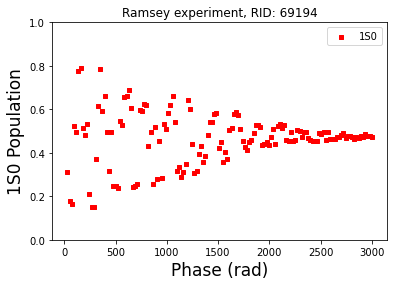

NameError: name 'x2' is not defined

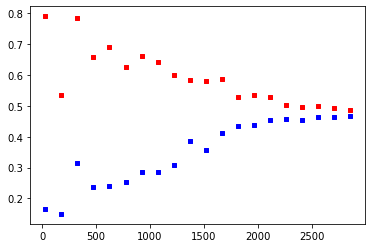

In [13]:
#f = np.linspace(0,len(ims),len(ims))
tmax = 3000
f = np.linspace(0,2*np.pi*len(ims)/100,len(ims))
tramsey = np.linspace(0.01*tmax,tmax,len(ims))
#techo = np.linspace(0.01*tmax,2*tmax,len(ims))

x0 = [np.sum(ims[i,bins[0]:bins[1],:])/np.sum(ims[i,bins[0]:bins[2],:]) for i in range(len(f))]
x1 = [np.sum(ims[i,bins[1]:bins[2],:])/np.sum(ims[i,bins[0]:bins[2],:]) for i in range(len(f))]
#x2 = [np.sum(ims[i,bins[2]:bins[3],:])/np.sum(ims[i,bins[0]:bins[3],:]) for i in range(len(f))]
#print(np.std(x0))
#print(np.std(x1))
#print(np.std(x2))
#x0XY=x0
#tXY = np.linspace(0.01*tmax,tmax,len(ims))
plt.scatter(tramsey,x0, label='1S0', c='red', marker='s',s=10)
#x00=x0
#plt.scatter(techo,x0, label='1S0', c='red', marker='s',s=10)
#plt.scatter(tramsey,x00, label='1S0, delta_689=0kHz', c='blue', marker='s',s=10)
plt.xlabel("Phase (rad)", fontsize=17)
plt.ylabel("1S0 Population", fontsize=17)
plt.legend()
plt.ylim(0,1)
plt.title(f"Ramsey experiment, RID: {RID}")
plt.show()

pkh = []
pkl = []
bsize =7
ts=np.linspace(0.01*tmax,tmax,int(len(ims)/bsize)+1)[0:-1]
for i in range(0, len(x0), bsize):
    chunk = x0[i:i+bsize]
    if len(chunk) == bsize:  # Ensure a full chunk of 3 elements
        pkh.append(max(chunk))
        pkl.append(min(chunk))
    else:
        # Handle cases where the last chunk might have fewer than 3 elements
        # For example, average remaining elements or discard them
        pass 

contrast = np.array(pkh)-np.array(pkl)

tsXY = ts
contrastXY = contrast

plt.scatter(ts,pkh, label='Max 1S0', c='red', marker='s',s=10)
plt.scatter(ts,pkl, label='Min 1S0', c='blue', marker='s',s=10)
plt.scatter(tramsey,x2, label='1S0', c='grey', marker='s',s=4)
plt.xlabel("Time (us)", fontsize=17)
#plt.xlabel("Shot", fontsize=17)
plt.ylabel("1S0 Population", fontsize=17)

popth, pcovh = curve_fit(gaus1,ts,pkh, p0=[400, 0.7,0.5], maxfev=20000)
poptl, pcovl = curve_fit(gaus1,ts,1-np.array(pkl), p0=[400, 0.7,0.5], maxfev=20000)
plt.plot(tramsey, gaus1(tramsey, *popth), c='r',label='Pk-pk')
plt.plot(tramsey, 1-gaus1(tramsey, *poptl), c='b',label='Pk-pk')
print(popth[0])
print(poptl[0])
print((poptl[0]+popth[0])/4)

plt.legend()
plt.ylim(0,1)
plt.show()

plt.scatter(ts,contrast, label='1S0', c='red', marker='s',s=10)
plt.xlabel("Time (us)", fontsize=17)
plt.ylabel("Contrast", fontsize=17)
plt.title(f"Ramsey experiment, RID: {RID}")
plt.ylim(0,1)

popt, pcov = curve_fit(gaus0,ts,contrast, p0=[183, 0.7], maxfev=20000)
plt.plot(ts, gaus0(ts, *popt), c='r',label='Pk-pk')
plt.legend()
plt.show()
print(popt[0])
print(np.sqrt(np.diag(pcov))[0])

In [421]:
ts

array([  30.  ,  401.25,  772.5 , 1143.75, 1515.  , 1886.25, 2257.5 ,
       2628.75])

<ipython-input-413-3891956907f8>:6: UserWarning: Attempted to set non-positive left xlim on a log-scaled axis.
Invalid limit will be ignored.
  plt.xlim(0,3000)


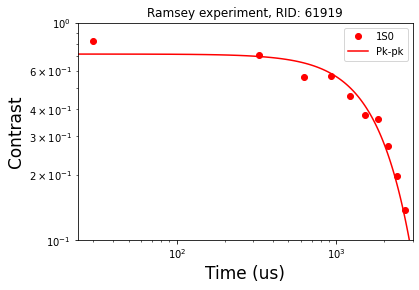

In [413]:
plt.loglog(ts,contrast, 'o',label='1S0', c='red')
plt.xlabel("Time (us)", fontsize=17)
plt.ylabel("Contrast", fontsize=17)
plt.title(f"Ramsey experiment, RID: {RID}")
plt.ylim(0.1,1)
plt.xlim(0,3000)

tfit = np.linspace(0,3000,100)
popt, pcov = curve_fit(gaus0,ts,contrast, p0=[183, 0.7], maxfev=20000)
plt.loglog(tfit, gaus0(tfit, *popt), c='r',label='Pk-pk')
plt.legend()
plt.show()

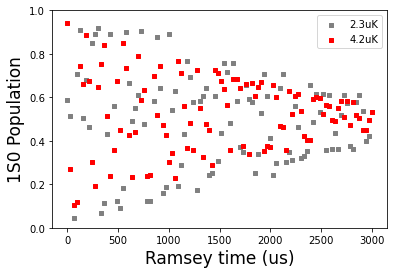

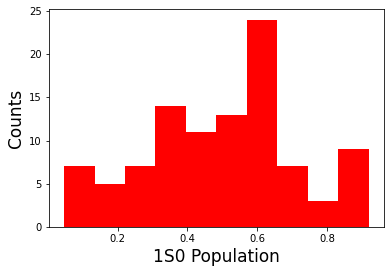

In [458]:
tmax = 3000
f = np.linspace(0,tmax,len(ims))
plt.scatter(f,x0, label='2.3uK', c='grey', marker='s',s=10)
plt.scatter(f,x00, label='4.2uK', c='red', marker='s',s=10)
plt.xlabel("Ramsey time (us)", fontsize=17)
plt.ylabel("1S0 Population", fontsize=17)
plt.legend()
plt.ylim(0,1)
#plt.title(f"Ramsey experiment, RID: {RID}")
plt.show()

plt.hist(x0, color='r')
#plt.hist(x00, color='b')
plt.ylabel("Counts", fontsize=17)
plt.xlabel("1S0 Population", fontsize=17)
plt.show()

In [460]:
print(np.sqrt(4.2/2.3))
2300/1950

1.3513278493843526


1.1794871794871795

<ipython-input-329-ba37d5862b58>:8: UserWarning: Attempted to set non-positive left xlim on a log-scaled axis.
Invalid limit will be ignored.
  plt.xlim(0,4000)


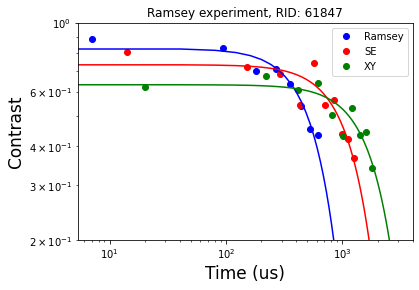

In [329]:
plt.loglog(tsR,contrastR, 'o',label='Ramsey', c='blue')
plt.loglog(tsSE,contrastSE, 'o',label='SE', c='red')
plt.loglog(tsXY,contrastXY, 'o',label='XY', c='green')
plt.xlabel("Time (us)", fontsize=17)
plt.ylabel("Contrast", fontsize=17)
plt.title(f"Ramsey experiment, RID: {RID}")
plt.ylim(0.2,1)
plt.xlim(0,4000)

tfit = np.linspace(0,4000,100)
popt, pcov = curve_fit(gaus0,tsR,contrastR, p0=[183, 0.7], maxfev=20000)
plt.loglog(tfit, gaus0(tfit, *popt), c='blue')

popt, pcov = curve_fit(gaus0,tsSE,contrastSE, p0=[183, 0.7], maxfev=20000)
plt.loglog(tfit, gaus0(tfit, *popt), c='r')

popt, pcov = curve_fit(gaus0,tsXY,contrastXY, p0=[183, 0.7], maxfev=20000)
plt.loglog(tfit, gaus0(tfit, *popt), c='g')
plt.legend()
plt.show()

<ipython-input-100-767145ead846>:7: UserWarning: Attempted to set non-positive left xlim on a log-scaled axis.
Invalid limit will be ignored.
  plt.xlim(0,2000)


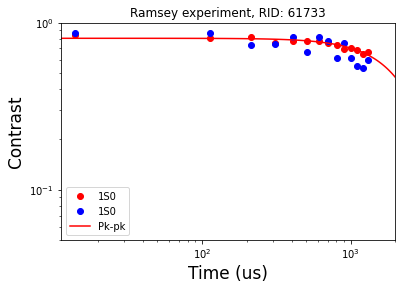

1923.9866953134515
101.93303270469688


In [100]:
plt.loglog(ts,pkh, 'o',label='1S0', c='red')
plt.loglog(ts,1-np.array(pkl), 'o',label='1S0', c='blue')
plt.xlabel("Time (us)", fontsize=17)
plt.ylabel("Contrast", fontsize=17)
plt.title(f"Ramsey experiment, RID: {RID}")
plt.ylim(0.05,1)
plt.xlim(0,2000)

tfit = np.linspace(0,2000,100)
popt, pcov = curve_fit(gaus0,ts,pkh, p0=[183, 0.7], maxfev=20000)
plt.loglog(tfit, gaus0(tfit, *popt), c='r',label='Pk-pk')
plt.legend()
plt.show()

print(popt[0])
print(np.sqrt(np.diag(pcov))[0])

In [22]:
#f = np.linspace(0,len(ims),len(ims))
f = np.linspace(0,2*np.pi,len(ims))

x0 = [np.sum(ims[i,bins[0]:bins[1],:])/np.sum(ims[i,bins[0]:bins[2],:]) for i in range(len(f))]
x1 = [np.sum(ims[i,bins[1]:bins[2],:])/np.sum(ims[i,bins[0]:bins[2],:]) for i in range(len(f))]
x2 = [np.sum(ims[i,bins[2]:bins[3],:])/np.sum(ims[i,bins[0]:bins[3],:]) for i in range(len(f))]
#print(np.std(x0))
#print(np.std(x1))
#print(np.std(x2))

pkh = []
pkl = []
bsize = 10
tmax = 400
ts = np.linspace(bsize/2,tmax,int(tmax/bsize))
for i in range(0, len(x0), bsize):
    chunk = x0[i:i+bsize]
    if len(chunk) == 10:  # Ensure a full chunk of 3 elements
        pkh.append(max(chunk))
        pkl.append(min(chunk))
    else:
        # Handle cases where the last chunk might have fewer than 3 elements
        # For example, average remaining elements or discard them
        pass 

    
#popt, pcov = curve_fit(Sine,f, x0, p0=[0.5, 4,0.5], maxfev=20000)
plt.plot(f, Sine(f, *popt), c='r')
#popt, pcov = curve_fit(gaus,f, x2, p0=[180, 2, 1], maxfev=20000)
#plt.plot(f, gaus(f, *popt), c='r')

plt.scatter(f,x0, label='1S0', c='red', marker='s',s=10)
#plt.errorbar(f,x0,stdevs,fmt='o',c='red', capsize=5, ecolor='red', elinewidth=1)
#plt.scatter(f,x1, label='3P1', c='green', marker='s',s=10)
#plt.scatter(f,x2, label='3P0', c='blue', marker='s',s=10)
plt.xlabel("Phase (rad)", fontsize=17)
#plt.xlabel("Shot", fontsize=17)
plt.ylabel("Population", fontsize=17)
plt.legend()
plt.ylim(0,1)

plt.title(f"Ramsey experiment, RID: {RID}")
plt.show()

plt.hist(x0,bins=20)
plt.xlabel("Population", fontsize=17)
plt.ylabel("Counts", fontsize=17)

plt.title(f"Ramsey experiment, RID: {RID}")
plt.show()

plt.scatter(f,x0-Sine(f, *popt), label='1S0', c='red', marker='s',s=10)
plt.xlabel("", fontsize=17)
plt.ylabel("Population", fontsize=17)
plt.legend()


plt.title(f"Ramsey experiment, RID: {RID}")
plt.show()

resid2 = x0-Sine(f, *popt)

print(np.max(x0)-np.min(x0))
print(2*popt[0])

TypeError: Sine() missing 1 required positional argument: 'y0'

In [670]:
times = [2,50,100,200,400]
pk = [.7790,0.7446,.6714,.4329,0.054]
fitted = [0.7635,0.6006,.5752,.1907,0.031]

C:\Users\sr\Anaconda3\lib\site-packages\scipy\optimize\minpack.py:828: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
C:\Users\sr\Anaconda3\lib\site-packages\scipy\optimize\minpack.py:828: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


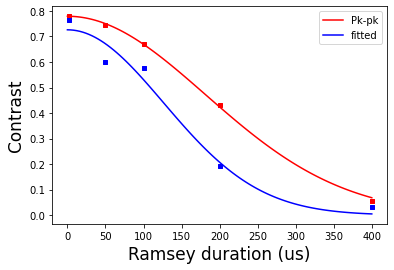

[181.26888136   0.77921406   0.        ]
[126.30996464   0.7260872    0.        ]


In [671]:
tcont = np.linspace(0,400,100)
plt.scatter(times,pk,c='red', marker='s',s=10)

plt.scatter(times,fitted,c='blue', marker='s',s=10)

plt.xlabel("Ramsey duration (us)", fontsize=17)
plt.ylabel("Contrast", fontsize=17)

popt, pcov = curve_fit(gaus0,times,pk, p0=[10, 1,0], maxfev=20000)
plt.plot(tcont, gaus0(tcont, *popt), c='r',label='Pk-pk')

popt2, pcov2 = curve_fit(gaus0,times,fitted, p0=[10, 1,0], maxfev=20000)
plt.plot(tcont, gaus0(tcont, *popt2), c='b',label='fitted')
plt.legend()
plt.show()

print(popt)
print(popt2)

In [371]:
# decaying sine
def expSine(x, A, f, phi, tau, y0):
    return (A*np.sin(2*np.pi*f*x+phi)*np.exp(-x**2/(tau**2))+y0)

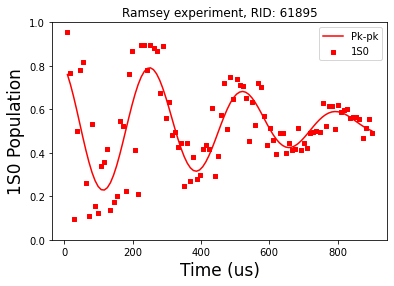

[3.09264053e-01 9.96355889e-01 1.05833709e+00 6.30588794e+02
 5.27288704e-01]
0.039278466812949414


In [375]:
plt.scatter(tramsey,x1, label='1S0', c='red', marker='s',s=10)
plt.xlabel("Time (us)", fontsize=17)
plt.ylabel("1S0 Population", fontsize=17)
plt.legend()
plt.ylim(0,1)

plt.title(f"Ramsey experiment, RID: {RID}")

popt, pcov = curve_fit(expSine,tramsey,x1, p0=[0.6, 1,0,200,0.5], maxfev=20000)
plt.plot(tramsey, expSine(tramsey, *popt), c='r',label='Pk-pk')
plt.legend()
plt.show()
print(popt)
print(np.sqrt(np.diag(pcov))[0])

[0.009548730978486011, 0.0073078831275058, 0.00834682380366509, 0.004478541426508195, 0.004381129847869533, 0.0011379382416918896, 0.0, 0.0, 0.00018361181124705803, 0.0017497746502344396, 0.005272407732864675, 0.008762533042533351]


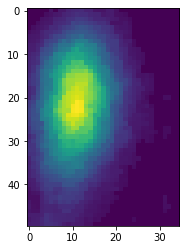

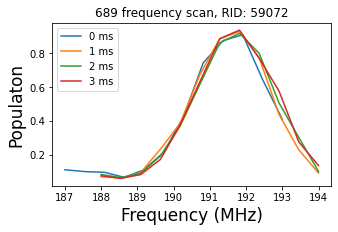

In [51]:
f = exp.x*1e-6
# for im in ims[:10]:
#     plt.imshow(im[bins[0]:bins[1],:])
#     plt.show()
# print(ims[0,bins[1]:bins[2],:].shape)
x0 = [np.sum(ims[i,bins[0]:bins[1],:])/np.sum(ims[i,bins[0]:bins[3],:]) for i in range(len(f))]
x1 = [np.sum(ims[i,bins[1]:bins[2],:])/np.sum(ims[i,bins[0]:bins[3],:]) for i in range(len(f))]
x2 = [np.sum(ims[i,bins[2]:bins[3],:])/np.sum(ims[i,bins[0]:bins[3],:]) for i in range(len(f))]

print(x0)
plt.imshow(ims[3,bins[1]:bins[2],:])
plt.show()
plt.figure(figsize=(5,3))

#plt.scatter(f, x0, label='1S0', c='r', marker='s',s=10)
#plt.scatter(f,x0, label='1S0', c='grey', marker='s',s=10)
#plt.scatter(f,x1, label='3P1', c='blue', marker='s',s=10)
plt.plot(f20,x20, label='0 ms')
plt.plot(f,x21, label='1 ms')
plt.plot(f,x22, label='2 ms')
plt.plot(f,x23, label='3 ms')


#plt.xlabel("Phase (turns)", fontsize=17)plt.xlabel("Phase (turns)", fontsize=17)
plt.xlabel("Frequency (MHz)", fontsize=17)
plt.ylabel("Populaton", fontsize=17)
plt.legend()

#plt.title(f"Ramsey Phase Scan, RID: {RID}")
plt.title(f"689 frequency scan, RID: {RID}")
plt.show()

In [54]:
df = pf.DataFrame(x2)
df.to_csv("C:/Users/sr/Downloads/rid58303_3P0.csv")

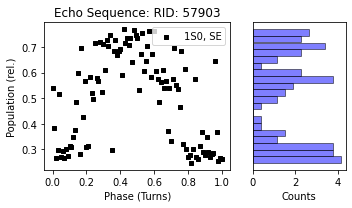

In [184]:
# Define a sinusoidal function
def sinusoidal(x, A, B, C):
    return A * np.sin(2*np.pi*x + B) + C

def batman(x, n, P0, C):
    return n/np.sqrt(1-((P0-x)/(C/2))**2)

# Fit the sinusoidal model to the data
#popt1, _ = curve_fit(sinusoidal, x1, y1, maxfev=20000)

# Generate smooth lines for the fit
#x_fit = np.linspace(0, 1, 1000)
#y_fit1 = sinusoidal(x_fit, *popt1)

# Create the figure and grid
fig, (ax1, ax2) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [2, 1]}, figsize=(5, 3))

# Plot scatter points and sinusoidal fit on the left
ax1.scatter(f,x1, label='1S0, SE', c='black', marker='s',s=10)
#ax1.plot(x_fit, y_fit1, label='Sinusoidal Fit', color='red')
ax1.set_xlabel('Phase (Turns)')
ax1.set_ylabel('Population (rel.)')
ax1.legend()
ax1.set_title(f"Echo Sequence: RID: {RID}")

# Plot the histogram on the right with the correct orientation
counts, bins, _ = ax2.hist(x1, bins=20, density=True, alpha=0.5, color='blue', orientation='horizontal', edgecolor='black')
bins = np.array(bins)
bins = (bins[1:] + bins[:-1])/2

#ax2.plot(batman(pop_fit,*[2, popt1[-1], 2*popt1[0]]), pop_fit,color='red' )
#ax2.plot(batman(pop_fit,*[2, popt2[-1], 2*popt2[0]]), pop_fit,color='red' )



# Label the histogram
ax2.set_xlabel('Counts')
ax2.set_yticks([])

# Add text annotations for contrast
#ax2.text(0.8, 0.5, f"C = {np.round(popt2[0], 3)}", transform=ax2.transAxes, ha="right", color='blue')

plt.tight_layout()

plt.show()

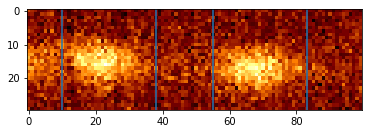

In [232]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

direc = "C:/Users/sr/Documents/Artiq/artiq-master/results"
RID = 49374

exp = ExpViewer(RID, dir=direc)
ims = exp.images



plt.imshow(ims[6][155:185, 150:250], cmap ='afmhot')
plt.axvline(10)
plt.axvline(38)
plt.axvline(55)
plt.axvline(83)

x = exp.x
port_1 = np.zeros(len(x))
port_2 = np.zeros(len(x))

for i in range(len(x)):
    im = ims[i][155:185, 150:250]
    im = np.where(im < 20, 0, im)
    port_1[i] = np.sum(im[:,10:38])
    port_2[i] = np.sum(im[:,55:83])

port_2 = port_2 / (port_2+port_1)    

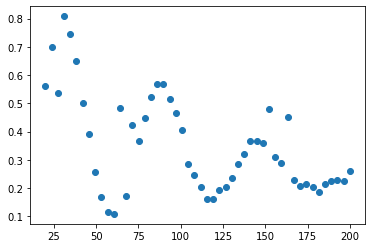

In [237]:
plt.scatter(x*1e6, port_2)


In [283]:


             
popt, pcov = curve_fit(expSine, x*1e6, port_2, p0=[0.5, .1, 4, 0.5, 0.5], maxfev=20000)          
plt.scatter(x*1e6, port_2)
t = np.linspace(x[0]*1e6, x[-1]*1e6, 1000)
print(popt)
plt.plot(t, 0.9*np.exp(-t/150)+0.1)

ValueError: operands could not be broadcast together with shapes (1000,) (50,) 

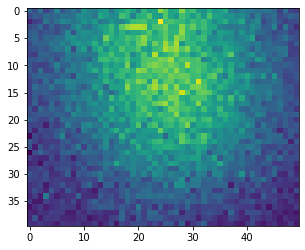

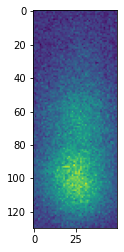

In [54]:
direc = "C:/Users/sr/Documents/Artiq/artiq-master/results"
RID = 52308

exp = ExpViewer(RID, dir=direc)
ims = np.array(exp.images)
plt.imshow(ims[0][130:170, 110:160])
plt.show()
plt.imshow(ims[0][40:170, 110:160])
plt.show()


In [65]:
res = np.zeros((15,16))

ii = 0
for rid in range(52290, 52307):
    if rid == 52303: continue
        
    exp = ExpViewer(rid, dir=direc)
    ims = exp.images
    transfer = [np.sum(ims[i][130:170, 110:160])/np.sum(ims[i][40:170, 110:160]) for i in range(15)]
    
    res[:, ii] = transfer
    ii += 1
    print(ii)
    


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16


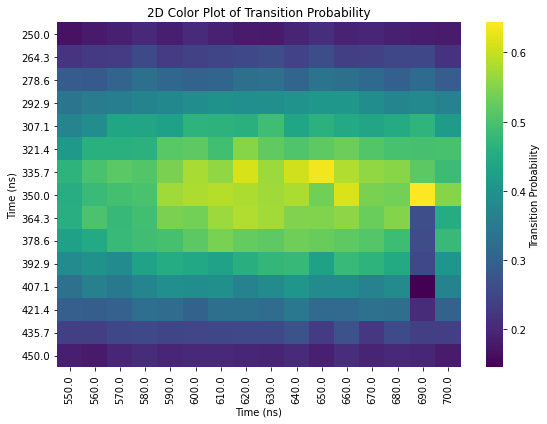

In [70]:

# Generate some sample data
x = np.linspace(550, 700, 16)
y = np.linspace(250, 450, 15)
# Z = np.sin(np.sqrt(X**2 + Y**2))  # transition probability (example)

# # Create the plot
plt.figure(figsize=(8, 6))
sns.heatmap(res, xticklabels=np.round(x, 1),
    yticklabels=np.round(y, 1), cmap='viridis', cbar_kws={'label': 'Transition Probability'})

# Configure the axes
plt.xlabel("Time (ns)")
plt.ylabel("Time (ns)")
plt.title("2D Color Plot of Transition Probability")
plt.tight_layout()

# Show the plot
plt.show()


In [68]:
exp = ExpViewer(52307, dir=direc)
ims = exp.images
transfer = [np.sum(ims[i][130:170, 110:160])/np.sum(ims[i][40:170, 110:160]) for i in range(15)]
res[:,10] = transfer

In [51]:
y[7]

350.0

(0.0, 5.0)

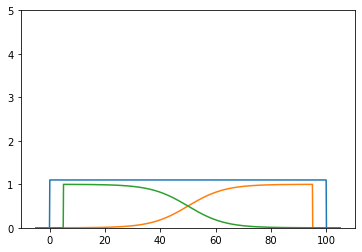

In [143]:
def sigmoid(z, sigma, sign):
    if (z<5)or (z>int_length-5): return 0
    return 1/(1 + np.exp(-sigma*(sign*(z-int_length/2))))

int_length = 100
t = np.linspace(-5, int_length+5, 1000)

pulse_688 = np.where((t>= 0)&(t<int_length), 1, 0) 
pulse_679 = np.zeros(len(t))
pulse_679 = np.array([sigmoid(i, 0.15, 1) for i in t])
pulse_689 = np.zeros(len(t))
pulse_689 = np.array([sigmoid(i, 0.15, -1) for i in t])

plt.plot(t, 1.1*pulse_688)
plt.plot(t, pulse_679)
plt.plot(t, pulse_689)
plt.ylim(0,5)


In [219]:
import numpy as np
from scipy.signal import gaussian
import matplotlib.pyplot as plt
import pyvisa

class WaveformGenerator:
    def __init__(self, sample_rate=10e6):
        self.sample_rate = sample_rate  # Samples per second
        self.time_array = np.array([])
        self.amplitude_array = np.array([])
        self.max = 1

    def add_square_pulse(self, start_time, duration, amplitude):
        t = np.arange(start_time, start_time + duration, 1/self.sample_rate)
        pulse = np.full_like(t, amplitude)
        self._append_pulse(t, pulse)

    def add_gaussian_pulse(self, start_time, duration, amplitude, std_dev):
        t = np.arange(start_time, start_time + duration, 1/self.sample_rate)
        t_centered = t - (start_time + duration / 2)
        
        pulse = amplitude * np.exp(-t_centered**2 / (2 * std_dev**2))
        self._append_pulse(t, pulse)
        
    def add_sigmoid_pulse(self, start_time, duration, amplitude, sigma, sign):
        t = np.arange(start_time, start_time + duration, 1/self.sample_rate)
        t_offset = start_time+duration/2  
        pulse = amplitude/(1 + np.exp(-sign*(t-t_offset)/sigma))
        self._append_pulse(t, pulse)
        
        

    def _append_pulse(self, t, pulse):
        if len(self.time_array) == 0:           
            # gap = np.arange(0, t[0], 1/self.sample_rate)
            # gap_amplitude = np.zeros_like(gap)
            
            self.time_array = t
            self.amplitude_array = pulse
        
        else:
            last_time = self.time_array[-1]
            if t[0] > last_time:
                # Fill in the gap with zeros if there's a delay
                gap = np.arange(last_time, t[0], 1/self.sample_rate)
                gap_amplitude = np.zeros_like(gap)
                self.time_array = np.concatenate([self.time_array, gap])
                self.amplitude_array = np.concatenate([self.amplitude_array, gap_amplitude])
            self.time_array = np.concatenate([self.time_array, t])
            self.amplitude_array = np.concatenate([self.amplitude_array, pulse])

    def get_waveform(self):
        self.max = np.max(self.amplitude_array)
        self.amplitude_array = self.amplitude_array/self.max
        return self.time_array, self.amplitude_array
        

    def reset_waveform(self):
        self.time_array = np.array([])
        self.amplitude_array = np.array([])


In [220]:
import pyvisa

rigol = pyvisa.ResourceManager().open_resource('USB0::0x1AB1::0x0641::DG4E232700930::INSTR')
rigol.write(":OUTP1 OFF");
rigol.write(":OUTP2 OFF");
wg = WaveformGenerator()

In [221]:
LENGTH = 100*1e-6
SAMPLES = 6000
SAMPLE_RATE = SAMPLES/LENGTH

wg.sample_rate = SAMPLE_RATE


wg.reset_waveform()
wg.add_sigmoid_pulse(5*1e-6, 90*1e-6, 1, 5*1e-6, +1)
t, y = wg.get_waveform()
val_str_ch1 = ",".join(map(str, y))

wg.reset_waveform()
wg.add_sigmoid_pulse(5*1e-6, 90*1e-6, 1, 5*1e-6, -1)
t, y = wg.get_waveform()
val_str_ch2 = ",".join(map(str, y))

waves = [val_str_ch1,val_str_ch2]

for i in range(1,3):
    rigol.write(f":OUTP{i} OFF");

    rigol.write(f":TRACE:DATA VOLATILE," + waves[i-1])
    rigol.write(f":SOUR{i}:APPL:USER {1/LENGTH}, {2*wg.max}, 0, 0")

    rigol.write(f"SOUR{i}:BURS ON")
    rigol.write(f"SOUR{i}:BURS:MODE TRIG")
    rigol.write(f":SOUR{i}:BURS:NCYC 1 ")
    rigol.write(f":SOUR{i}:BURS:TRIG:SOUR EXT")


    rigol.write(f":OUTP{i} ON");

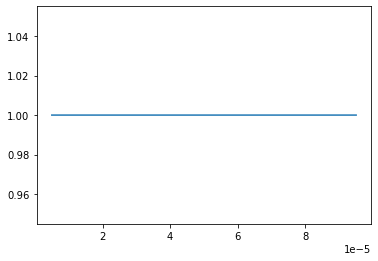

In [187]:
y

array([1., 1., 1., ..., 1., 1., 1.])

9.999999999999999e-05


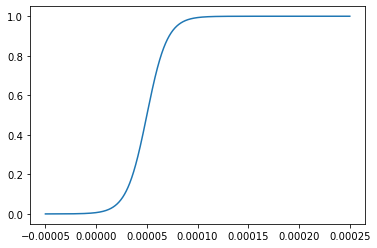

In [214]:
start_time = -50e-6
duration=300e-6
sample_rate=5000
sigma=10e-6
t_offset=50e-6

t = np.linspace(start_time, start_time + duration, sample_rate)
print(start_time+duration/2)
pulse = 1/(1 + np.exp(-(t-t_offset)/sigma))
plt.plot(t, pulse)

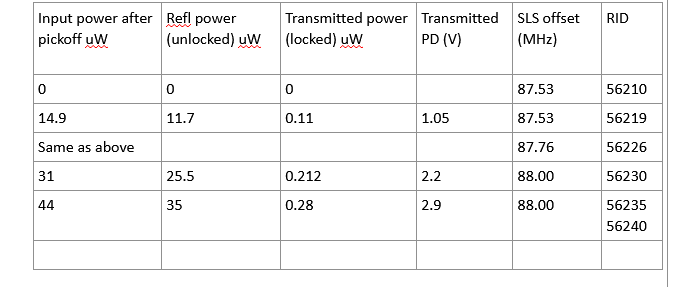

In [123]:
direc = "C:/Users/sr/Documents/Artiq/artiq-master/results"
RIDs = [56252, 56261, 56263, 56266, 56273, 56275]
# input_power = [0, 14.9, 14.9, 31, 44, 44]
# refl_power = [0, 11.7, 11.7, 25.5, 35, 35]
# trans_power = [0, 0.11, 0.11, 0.212, 0.28, 0.28]
# trans_pd = [0, 1.05, 1.05, 2.2, 2.9, 2.9]
# SLS_offset = [87.53, 87.53, 87.76, 88, 88, 88]

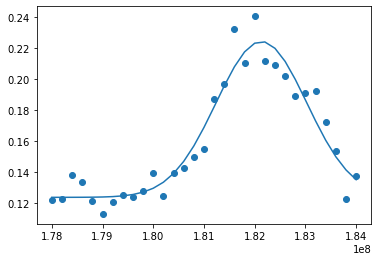

[  0.           0.           0.           0.         182.13224784
   0.        ]


In [185]:

def gaussian(x, A, mu, sigma, y0):
    return A*np.exp(-(x-mu)**2/2/sigma**2)+y0

def get_center(ind):
    
    RID = RIDs[ind]
    exp = ExpViewer(RID, dir=direc)
    ims = [im[120:200, 72:95] for im in exp.images]
#     ims = exp.images
    
#     for i in [0,5,10,15,20,25]:
#         plt.imshow(ims[i])
#         plt.show()
#     return 0
    port1 = np.array([np.sum(im[:60, :]) for im in ims])
    port2 = np.array([np.sum(im[60:, :]) for im in ims])
    
    ratio = port2/(port1+port2)
    f = exp.x
#     ratio = exp.y
    plt.scatter(f, ratio)
    
    guess = [1e6, f[np.argmax(ratio)], 200e3, 1e5]
    popt, pcov = curve_fit(gaussian,f, ratio, maxfev=20000, p0 = guess)
    plt.plot(f, gaussian(f, *popt))
    plt.show()
    
    return popt[1]*1e-6 
    
res = np.zeros(6)
ind = 4
res[ind] = get_center(ind)
print(res)
res -= res[0]

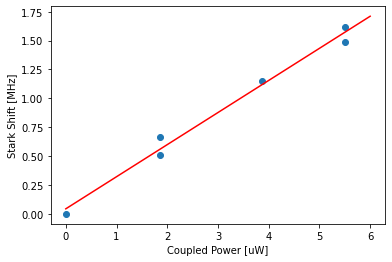

[0.27771946 0.04410813]


In [119]:
def linear(x, m, b):
    return m*x+b
coupled_power = 0.125*np.array(input_power)
plt.scatter(coupled_power, res)
popt, _ = curve_fit(linear, coupled_power, res)
x = np.linspace(0, 6, 100)
plt.plot(x, linear(x, *popt), label='fit', color="red")
plt.ylabel("Stark Shift [MHz]")
plt.xlabel("Coupled Power [uW]")
plt.show()
print(popt)

In [ ]:
plt.plot(x, linear(x, *popt), label='fit', color="red")
plt.ylabel("Stark Shift [MHz]")
plt.xlabel("Coupled Power [uW]")
plt.show()
print(popt)



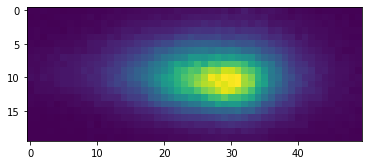

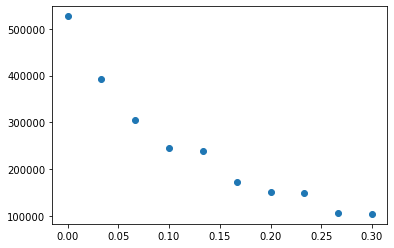

In [31]:
direc = "C:/Users/sr/Documents/Artiq/artiq-master/results"
exp = ExpViewer(56464, dir=direc)
plt.imshow(exp.images[0][180:200, 50:100])
plt.show()

t = exp.x
y = [np.sum(im[180:200, 50:100]) for im in exp.images]
plt.scatter(t,y)

17.19994793249445


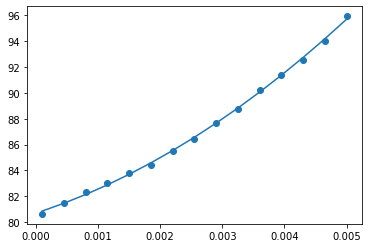

In [23]:
data = exp.saved_data['gaussianparams']
A, center_y, center_x, sigma_y_2, sigma_x_2, offset = data[:,0], data[:,1], data[:,2], data[:,3],data[:,4], data[:,5]
t=exp.x

def quadratic(x,a,b,c):
    return a*x**2+b*x+c

plt.scatter(t, center_y)
###fit falling atoms to get pixels to micron
popt, _ = curve_fit(quadratic,t,center_y,maxfev=20000);
plt.plot(t,quadratic(t,*popt))

###g/2 = a pixels/ms^2 = 9.8m/s^2 =
pix2um = 9.81e6/(popt[0]*2)
print(pix2um)

sigma_y_2*=pix2um**2
sigma_x_2*=pix2um**2

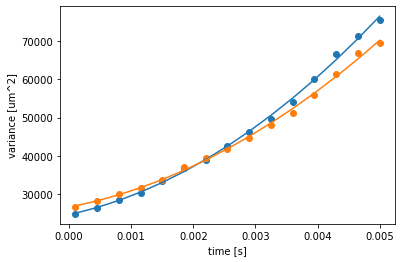

[1.36495103e+09 3.58124066e+06 2.45467005e+04] [1.12069778e+09 3.14579333e+06 2.65261927e+04]


In [24]:

plt.scatter(t,sigma_x_2);
plt.scatter(t,sigma_y_2);

popt1, _ = curve_fit(quadratic,t,sigma_x_2,maxfev=20000);
plt.plot(t,quadratic(t,*popt1))

popt2, _ = curve_fit(quadratic,t,sigma_y_2,maxfev=20000);
plt.plot(t,quadratic(t, *popt2))

plt.xlabel('time [s]')
plt.ylabel('variance [um^2]')

plt.show()
print(popt1,popt2)

In [26]:
from scipy import constants
M  = constants.value('atomic mass constant')*87.9
Kb = constants.value('Boltzmann constant')
tempX = popt1[0]*1e-12*M/Kb * 1e6
print(tempX, tempY)
tempY = popt2[0]*1e-12*M/Kb * 1e6

14.430180399179731 11.847949657388835


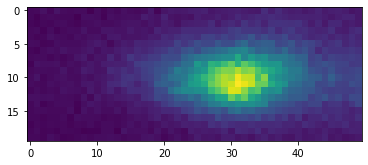

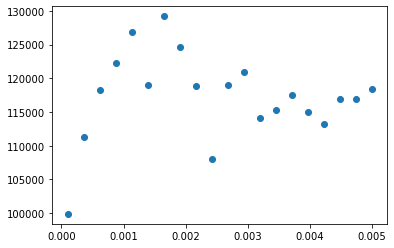

In [88]:
direc = "C:/Users/sr/Documents/Artiq/artiq-master/results"
exp = ExpViewer(56509, dir=direc)
plt.imshow(exp.images[0][180:200, 50:100])
plt.show()

t = exp.x
y = [np.sum(im[180:200, 50:100]) for im in exp.images]
plt.scatter(t,y)

## Dipole Trap Frequency

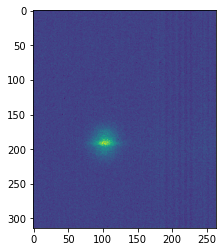

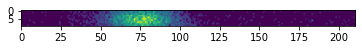

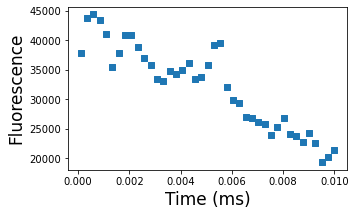

In [160]:
# extract and process images
direc = "C:/Users/sr/Documents/Artiq/artiq-master/results"
RID = 56521

exp = ExpViewer(RID, dir=direc)
# print(exp.parameters)
ims = np.array(exp.images)

plt.imshow(exp.images[0])  # check that image looks good
plt.show()

ims = ims[:,186:196,50:261]
threshold = 10
ims = np.where(ims > threshold, ims, 0)

plt.imshow(ims[12])  # check that processed image looks good
plt.show()

time = exp.x

plt.figure(figsize=(5, 3))

signal = [np.sum(ims[i]) for i in range(len(f1))]

plt.scatter(time, signal, marker='s')


plt.xlabel("Time (ms)", fontsize=17)
plt.ylabel("Fluorescence", fontsize=17)

plt.show()



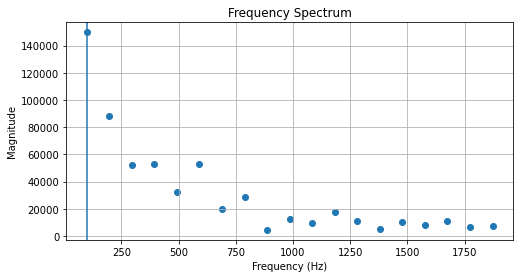

98.54644000985463

In [164]:
dt = np.mean(np.diff(time))  # Time difference between successive points

# Compute the FFT
N = len(signal)  # Number of data points
freqs = np.fft.fftfreq(N, d=dt)  # Frequency axis
fft_values = np.fft.fft(signal)  # Compute FFT

# Plot the magnitude spectrum
plt.figure(figsize=(8, 4))
plt.scatter(freqs[1:N//2], np.abs(fft_values[1:N//2]))  # Plot positive frequencies
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Frequency Spectrum")
plt.grid()
center = get_freq(time, signal)

plt.axvline(center)
plt.show()

center

In [136]:
def get_freq(time, signal):
    dt = np.mean(np.diff(time))  # Time difference between successive points

    # Compute the FFT
    N = len(signal)  # Number of data points
    freqs = np.fft.fftfreq(N, d=dt)  # Frequency axis
    fft_values = np.fft.fft(signal)  # Compute FFT
    return freqs[1+np.argmax(np.abs(fft_values[1:N//2]))]


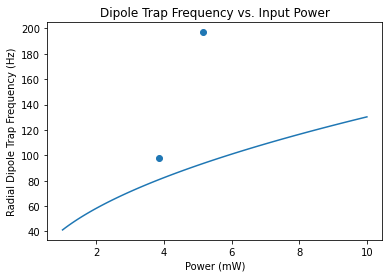

In [168]:
PI =  np.pi
c = cts.c
lamb = 813e-9
Gamma = 2*PI * 32e6
omega = 2*PI * c/lamb
omega_0 = 2*PI * c/(461e-9)
delta = omega-omega_0
Gamma/delta
alpha = 283 * 2.48832e-8*cts.hbar*2*PI

P = np.linspace(1,10,100)*1e-3
F = 7000
w0 = 100e-6
A = PI * (w0**2)
I0 = F*2*P/A
M = 88 * 1.66e-27


f = np.sqrt(alpha*I0 / ( 2 * cts.epsilon_0 * c * M * w0**2  ) )/(2*PI)

RIDs = [56512, 56521]
attens = np.array([12, 14, 16, 18])
V_dip = np.array([0.6, 0.5 ])
V_peak = np.array([1.4, 1.2, 0.81, 0.647])
P_meas= (V_peak-V)/1.4 * 9
f_meas = np.array([197, 98])

plt.scatter(P_meas[:2], f_meas, label='Measurement')
plt.plot(P*1e3, f/2, label="Theory")

# plt.axhline(380)
plt.xlabel("Power (mW)")
plt.ylabel("Radial Dipole Trap Frequency (Hz)")
plt.title("Dipole Trap Frequency vs. Input Power")
plt.show()


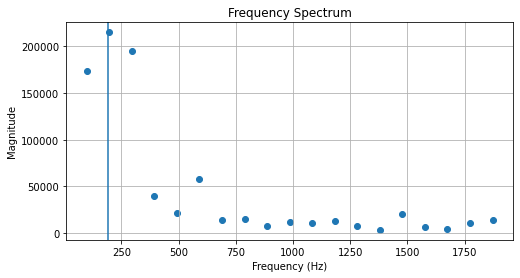

197.09288001970927

In [109]:
cts.epsilon_0*3e8

0.0026562563438400004

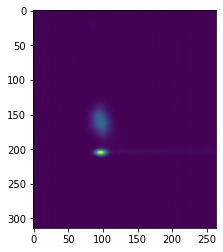

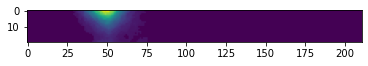

NameError: name 'signal' is not defined

<Figure size 360x216 with 0 Axes>

In [12]:
# extract and process images
direc = "C:/Users/sr/Documents/Artiq/artiq-master/results"
RID = 64241

exp = ExpViewer(RID, dir=direc)
# print(exp.parameters)
ims = np.array(exp.images)

plt.imshow(exp.images[12])  # check that image looks good
plt.show()

ims = ims[:,176:196,50:261]
threshold = 10
ims = np.where(ims > threshold, ims, 0)

plt.imshow(ims[12])  # check that processed image looks good
plt.show()

freq = exp.x
ampl = exp.y

plt.figure(figsize=(5, 3))

plt.scatter(freq, signal, marker='s')


plt.xlabel("Freq (MHz)", fontsize=17)
plt.ylabel("Fluorescence", fontsize=17)

plt.show()

In [ ]:
##fit each RID with sinc function - peak and standard error 
#plotted vs PD voltage
#for m=0 and m=1

## 2d ramsey scan

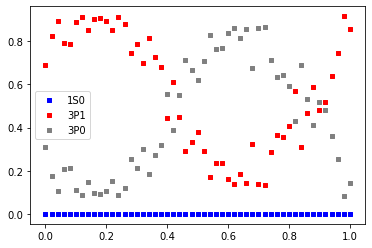

0.2689548292078552


In [398]:
# extract and process images

direc = "C:/Users/sr/Documents/Artiq/artiq-master/results"
RID = 72178

exp = ExpViewer(RID, dir=direc)
ims = np.array(exp.images)

#plt.imshow(exp.images[5])  # check that image looks good
#plt.show()

ims = ims[0:51,100:300, 55:120]
threshold = 10
ims = np.where(ims > threshold, ims, 0)

bins = (1, 85, 135,175)
#for val in bins:
#    plt.axhline(val, color='red')
#plt.imshow(1-ims[10],cmap=plt.get_cmap('Blues'))  # check that processed image looks good
#plt.show()
#plt.imshow(1-ims[1],cmap=plt.get_cmap('Blues'))  # check that processed image looks good
#plt.show()

f = np.linspace(0,1,51)

x0 = [np.sum(ims[i,bins[0]:bins[1],:])/np.sum(ims[i,bins[0]:bins[3],:]) for i in range(len(ims))]
x1 = [np.sum(ims[i,bins[1]:bins[2],:])/np.sum(ims[i,bins[0]:bins[3],:]) for i in range(len(ims))]
x2 = [np.sum(ims[i,bins[2]:bins[3],:])/np.sum(ims[i,bins[0]:bins[3],:]) for i in range(len(ims))]

plt.scatter(f,x0, label='1S0', c='blue', marker='s',s=10)
plt.scatter(f,x1, label='3P1', c='red', marker='s',s=10)
plt.scatter(f,x2, label='3P0', c='gray', marker='s',s=10)
plt.legend()
plt.show()

print(np.std(x2))

0.9381467093745739


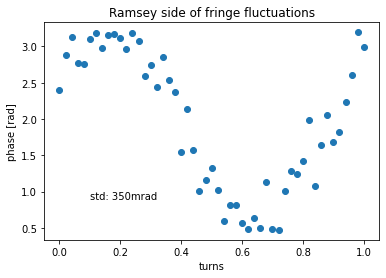

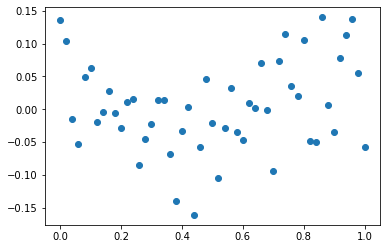

In [399]:
#slope 0.9/pi radians 
plt.scatter(f,np.array(x1)*np.pi/.9)
print(np.std(np.array(x1)*np.pi/.9))
plt.xlabel('turns'); plt.ylabel('phase [rad]')
plt.title('Ramsey side of fringe fluctuations');
plt.text(0.1, .9, 'std: 350mrad')

deriv=np.gradient(x1); deriv[25]
plt.show(); plt.scatter(f,deriv)

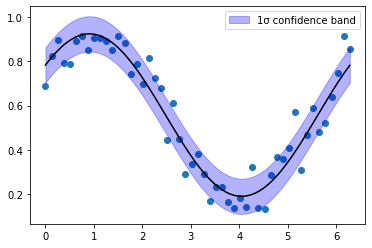

In [423]:
popt, pcov = curve_fit(Sine,p,x1, absolute_sigma=False,p0=[1, 1,0], maxfev=20000)

# residuals
residuals = x1 - Sine(p, *popt)
dof = len(p) - len(popt)
sigma2 = np.sum(residuals**2) / dof

# variance from parameters
y_var_model = np.einsum('ij,jk,ik->i', J, pcov, J)

# prediction variance
y_var_pred = y_var_model + sigma2

y_std = np.sqrt(y_var_pred)


plt.scatter(p,x1)
#plt.scatter(p, Sine(p, *popt), s=10, alpha=0.6)
plt.plot(xfit, Sine(xfit, *popt), color='black')

plt.fill_between(
    xfit,
    Sine(xfit, *popt) - y_std,
    Sine(xfit, *popt) + y_std,
    alpha=0.3,
    color='blue',
    label='1σ confidence band'
)

plt.legend()
plt.show()


In [424]:
np.mean(y_std*1/.33)

0.24063994169832342

Text(-0.4, 8, 'std 294mrad')

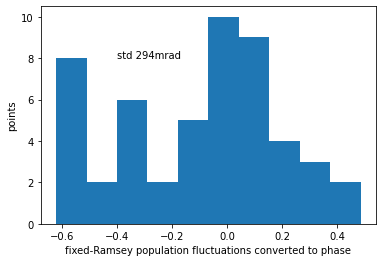

In [397]:
plt.hist(np.array(x1)*-1/.344+1.2)
np.std(np.array(x1)*-1/.344)
plt.ylabel('points'); plt.xlabel('fixed-Ramsey population fluctuations converted to phase')
plt.text(-.4,8,'std 294mrad')